# Importing required packages

In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

In [3]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import cellcharter as cc
import matplotlib.pyplot as plt
import yaml
import squidpy as sq
from pathlib import Path

# Required inputs

In [4]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
metadata_dir = Path(config['metadata_dir'])
results_dir = Path(config['results_dir'])

In [5]:
#read the adata object
adata = ad.read(results_dir / 'adata_unified.h5ad')

/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/anndata/__init__.py:42: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


# Preparing the adata

In [11]:
#arcsinh transform the data
adata.X = np.arcsinh(adata.X)
sc.pp.scale(adata)
adata.X = adata.X.astype(np.float32).copy()
condition_key = 'patient_ID'
cell_type_key = 'cell_type'
conditions = adata.obs[condition_key].unique().tolist()

# Training TRVAE

In [12]:
trvae_epochs = 500
surgery_epochs = 500

early_stopping_kwargs = {
    "early_stopping_metric": "val_unweighted_loss",
    "threshold": 0,
    "patience": 20,
    "reduce_lr": True,
    "lr_patience": 13,
    "lr_factor": 0.1,
}

trvae = cc.tl.TRVAE(
    adata=adata,
    condition_key=condition_key,
    conditions=conditions,
    recon_loss='mse',
    use_mmd=True,
)
trvae.train(
    n_epochs=trvae_epochs,
    alpha_epoch_anneal=200,
    early_stopping_kwargs=early_stopping_kwargs,
    enable_progress_bar=True,
    
)
trvae.save('trvae', overwrite=True)


INITIALIZING NEW NETWORK..............
Encoder Architecture:
	Input Layer in, out and cond: 63 256 12
	Hidden Layer 1 in/out: 256 64
	Mean/Var Layer in/out: 64 10
Decoder Architecture:
	First Layer in, out and cond:  10 64 12
	Hidden Layer 1 in/out: 64 256
	Output Layer in/out:  256 63 

Preparing (521687, 63)
Instantiating dataset
 |█-------------------| 8.8%  - val_loss: 114.1166393430 - val_recon_loss: 21.1140627253 - val_kl_loss: 40.9848162240 - val_mmd_loss: 84.1908407492
ADJUSTED LR
 |██------------------| 10.2%  - val_loss: 112.3391950271 - val_recon_loss: 16.4519864181 - val_kl_loss: 40.9970013020 - val_mmd_loss: 85.6379583583
Stopping early: no improvement of more than 0 nats in 20 epochs
If the early stopping criterion is too strong, please instantiate it with different parameters in the train method.
Saving best state of network...
Best State was in Epoch 29


In [14]:
model = cc.tl.TRVAE.load(
    'trvae', 
    adata, 
    map_location='cpu'
)
adata.obsm['X_trvae']= model.get_latent(adata.X, adata.obs['patient_ID'])

AnnData object with n_obs × n_vars = 521687 × 63
    obs: 'cell_id', 'cell_type', 'level', 'parent_cell', 'type_no', 'Cell 3D Volume', 'Cell Bbox Bottom', 'Cell Bbox Left', 'Cell Bbox Right', 'Cell Bbox Top', 'Cell Bbox X Size', 'Cell Bbox Y Size', 'Cell Center X', 'Cell Center Y', 'Cell Center Y Inverted', 'Cell Contour Bending Energy', 'Cell Contour Length', 'Cell Convex Hull Area', 'Cell Convex Hull Perimeter', 'Cell Convexity', 'Cell Cytoplasm Area', 'Cell Feret Diameter Max', 'Cell Feret Diameter Maximum Angle', 'Cell Feret Diameter Min', 'Cell Feret Diameter Minimum Angle', 'Cell Feret Diameter Perpendicular Min', 'Cell P2A', 'Cell Radius Maximum', 'Cell Radius Mean', 'Cell Radius Minimum', 'Cell Radius Standard Deviation', 'Cell Roundness', 'Cell Shape Circle Like', 'Cell Shape Ellipse Like', 'Cell Shape Elongation', 'Cell Shape Square Like', 'Cell Shape Triangle Like', 'Cell Size', 'Nuc X', 'Nuc Y', 'Nuc Y Inv', 'Nucleus 3D Volume', 'Nucleus Box Bottom', 'Nucleus Box Height', '

In [23]:
model_params = {
    'random_state': 42,
    'trainer_params': {
        'accelerator':'cpu',
        'enable_progress_bar': False
        },
    }


In [24]:
#per patient analysis
from joblib import Parallel, delayed
patients = adata.obs["patient_ID"].unique()
def process_exp(patient, adata):
    adata_select = adata[adata.obs["patient_ID"] == patient]
    sq.gr.spatial_neighbors(adata_select, library_key='exp_name', coord_type='generic', delaunay=True)
    adata_select.uns["spatial"] = {roi: {} for roi in adata_select.obs['exp_name'].unique()}
    cc.gr.remove_long_links(adata_select)
    cc.gr.aggregate_neighbors(adata_select, n_layers=3)
    autok = cc.tl.ClusterAutoK(n_clusters=(3,20), model_class=cc.tl.GaussianMixture, 
                           model_params=model_params, 
                           max_runs=5)
    autok.fit(adata_select, use_rep='X_cellcharter')
    ax = cc.pl.autok_stability(autok, return_ax=False, save=f'figures/autok_stability_{patient}.png')
    k = autok.best_k
    return k, patient

/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
100%|██████████| 4/4 [00:00<00:00, 34.36it/s]


Iteration 1/5


100%|██████████| 20/20 [07:39<00:00, 22.99s/it]


Iteration 2/5


100%|██████████| 20/20 [06:52<00:00, 20.61s/it]


...

100%|██████████| 20/20 [12:28<00:00, 37.43s/it]


Iteration 4/5


100%|██████████| 20/20 [23:56<00:00, 71.84s/it] 


Iteration 5/5


100%|██████████| 20/20 [08:16<00:00, 24.80s/it]


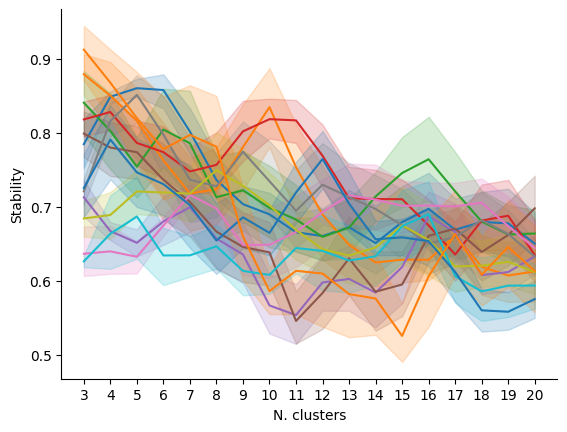

In [25]:
results = [process_exp(patient, adata) for patient in patients]


In [30]:
results_df = pd.DataFrame(results, columns=['optimal_k', 'patient'])
results_df.to_csv(results_dir / 'optimal_k_per_patient.csv', index=False)

In [38]:
k_data = pd.read_csv(results_dir / 'optimal_k_per_patient.csv')


In [39]:
patients = adata.obs["patient_ID"].unique()
def apply_cellcharter(patient, adata, k_data):
    adata_select = adata[adata.obs["patient_ID"] == patient]
    k_data_select = k_data[k_data["patient"] == patient]
    k = k_data_select["optimal_k"].values[0]
    sq.gr.spatial_neighbors(adata_select, library_key='exp_name', coord_type='generic', delaunay=True)
    adata_select.uns["spatial"] = {roi: {} for roi in adata_select.obs['exp_name'].unique()}
    cc.gr.remove_long_links(adata_select)
    cc.gr.aggregate_neighbors(adata_select, n_layers=3, use_rep='X_trvae')
    gmm = cc.tl.Cluster(
        n_clusters=k,
        random_state=12345,
        trainer_params=dict(accelerator='cpu', devices=1))
    gmm.fit(adata_select, use_rep='X_cellcharter')
    adata_select.obs['spatial_cluster'] = gmm.predict(adata_select, use_rep='X_cellcharter')
    sq.pl.spatial_scatter(
    adata_select, 
    color='spatial_cluster',
    library_key = "exp_name",
    img=None,
    title = adata_select.obs.exp_name.unique(), 
    size=20,
    ncols=1,
    library_id=adata_select.obs.exp_name.unique())
    sc.pl.spatial(adata_select, color="cell_type", show=True, cmap="tab20", spot_size=60, img_key=None)
    cc.gr.enrichment(adata_select, group_key='spatial_cluster', label_key='cell_type', pvalues=True)
    cc.pl.enrichment(adata_select, group_key='spatial_cluster', label_key='cell_type', figsize=(5,5), fontsize=6, dot_scale=1, group_cluster=True)

In [43]:
patient = "NMC_14"

In [44]:
adata_select = adata[adata.obs["patient_ID"] == patient]
k_data_select = k_data[k_data["patient"] == patient]
k = k_data_select["optimal_k"].values[0]
sq.gr.spatial_neighbors(adata_select, library_key='exp_name', coord_type='generic', delaunay=True)
adata_select.uns["spatial"] = {roi: {} for roi in adata_select.obs['exp_name'].unique()}
cc.gr.remove_long_links(adata_select)
cc.gr.aggregate_neighbors(adata_select, n_layers=3, use_rep='X_trvae')
gmm = cc.tl.Cluster(
    n_clusters=k,
    random_state=12345,
    trainer_params=dict(accelerator='cpu', devices=1))
gmm.fit(adata_select, use_rep='X_cellcharter')
adata_select.obs['spatial_cluster'] = gmm.predict(adata_select, use_rep='X_cellcharter')
sq.pl.spatial_scatter(
    adata_select, 
    color='spatial_cluster',
    library_key = "exp_name",
    img=None,
    title = adata_select.obs.exp_name.unique(), 
    size=20,
    ncols=1,
    library_id=adata_select.obs.exp_name.unique())
sc.pl.spatial(adata_select, color="cell_type", show=True, cmap="tab20", spot_size=60, img_key=None)


/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/squidpy/gr/_utils.py:203: ImplicitModificationWarning: Setting element `.obsp['spatial_connectivities']` of view, initializing view as actual.
  obj[key] = data
100%|██████████| 4/4 [00:00<00:00, 50.99it/s]
/Users/jawadalaaedeen/miniconda3/envs/cellcharter-env/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


AssertionError: 

In [ ]:
cc.gr.enrichment(adata_select, group_key='spatial_cluster', label_key='cell_type', pvalues=True)
cc.pl.enrichment(adata_select, group_key='spatial_cluster', label_key='cell_type', figsize=(5,5), fontsize=6, dot_scale=1, group_cluster=True)

In [ ]:
#all i want is cluster stability analysis per sample....